<a href="https://colab.research.google.com/github/itsyogi01/PYTHON--45DAYS-PRACTICE/blob/main/ml_project01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
import numpy as np
import pandas as pd


In [61]:
df = pd.read_csv('https://raw.githubusercontent.com/itsyogi01/PYTHON--45DAYS-PRACTICE/refs/heads/main/Placement.csv')
df

,Student_ID,CGPA,IQ,Placement
0,1,6.8,123,1
1,2,5.9,106,0
2,3,5.3,121,0
3,4,7.4,132,1
4,5,5.8,142,0
...,...,...,...,...
95,96,4.3,200,0
96,97,4.4,42,0
97,98,6.7,182,1
98,99,6.3,103,1


In [62]:
df.head()

,Student_ID,CGPA,IQ,Placement
0,1,6.8,123,1
1,2,5.9,106,0
2,3,5.3,121,0
3,4,7.4,132,1
4,5,5.8,142,0


In [63]:
# preprocessing
df.drop('Student_ID',axis=1,inplace=True)


df

,CGPA,IQ,Placement
0,6.8,123,1
1,5.9,106,0
2,5.3,121,0
3,7.4,132,1
4,5.8,142,0
...,...,...,...
95,4.3,200,0
96,4.4,42,0
97,6.7,182,1
98,6.3,103,1


In [64]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   CGPA       100 non-null    float64
 1   IQ         100 non-null    int64  
 2   Placement  100 non-null    int64  
dtypes: float64(1), int64(2)
memory usage: 2.5 KB


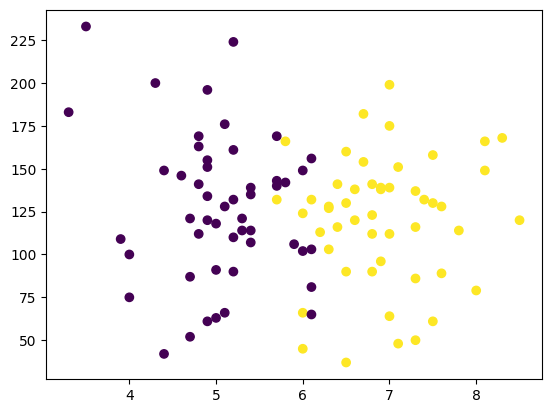

In [65]:
import matplotlib.pyplot as plt
plt.scatter(df['CGPA'],df['IQ'],c=df['Placement'])

In [66]:
X = df.iloc[:,0:2]
print(X)
Y = df.iloc[:,-1]
print(Y)

    CGPA   IQ
0    6.8  123
1    5.9  106
2    5.3  121
3    7.4  132
4    5.8  142
..   ...  ...
95   4.3  200
96   4.4   42
97   6.7  182
98   6.3  103
99   6.2  113

[100 rows x 2 columns]
0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: Placement, Length: 100, dtype: int64


In [67]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.1)
X_train


,CGPA,IQ
17,3.3,183
68,4.0,75
73,4.9,61
45,6.0,66
1,5.9,106
...,...,...
14,6.1,103
54,6.4,141
43,6.8,141
56,6.1,65


In [68]:
Y_train


,Placement
17,0
68,0
73,0
45,1
1,0
...,...
14,0
54,1
43,1
56,0


In [69]:
X_test

,CGPA,IQ
22,4.9,120
52,7.0,175
23,4.7,87
74,6.7,154
65,8.1,166
41,5.4,114
31,3.9,109
77,7.3,50
98,6.3,103
36,5.7,140


In [70]:
Y_test

,Placement
22,0
52,1
23,0
74,1
65,1
41,0
31,0
77,1
98,1
36,0


In [71]:
# scalling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_train
X_test = scaler.transform(X_test)
X_test

array([[-0.9683163 , -0.09417553],
       [ 0.89724722,  1.27690935],
       [-1.14598902, -0.91682645],
       [ 0.63073814,  0.75340422],
       [ 1.87444716,  1.05255001],
       [-0.52413451, -0.24374842],
       [-1.85667989, -0.3683925 ],
       [ 1.16375629, -1.83919265],
       [ 0.27539271, -0.5179654 ],
       [-0.25762544,  0.40440079]])

In [72]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
# model training
clf.fit(X_train,Y_train)

LogisticRegression()

In [73]:
# Evaluate the model
y_predict = clf.predict(X_test)
y_predict

array([0, 1, 0, 1, 1, 0, 0, 1, 1, 0])

In [74]:
Y_test

,Placement
22,0
52,1
23,0
74,1
65,1
41,0
31,0
77,1
98,1
36,0


In [75]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_test,y_predict)

1.0

<Axes: >

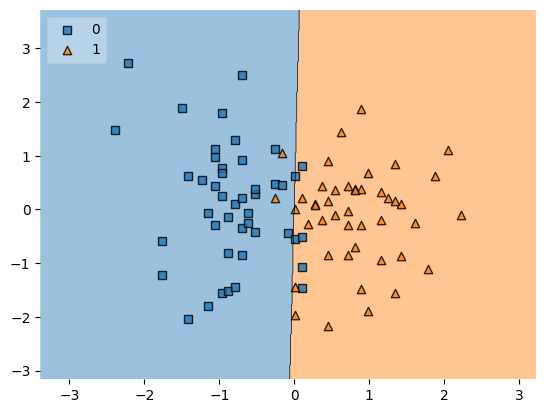

In [76]:
# Install mlxtend library
# !pip install mlxtend

# Import the function
from mlxtend.plotting import plot_decision_regions

# Plot decision regions for your classifier
plot_decision_regions(X_train,Y_train.values, clf=clf, legend=2)


In [59]:
import joblib
joblib.dump(clf, 'model.pkl')
model = joblib.load('model.pkl')
